PyTorch Version: 2.11.0+cu130
Device: cuda
GPU: Tesla T4

Tensor:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
Data type: torch.float32
Device: cpu
Tensor moved to: cuda:0


100%|██████████| 170M/170M [17:37<00:00, 161kB/s]



Training Images: 50000
Testing Images: 10000

Single image shape: torch.Size([3, 32, 32])
Label number: 6
Label name: frog

Training batches: 1563
Testing batches: 313

Batch image shape: torch.Size([32, 3, 32, 32])
Batch label shape: torch.Size([32])

First 10 labels:
tensor([9, 8, 7, 8, 7, 3, 2, 7, 0, 2])

First image shape:
torch.Size([3, 32, 32])


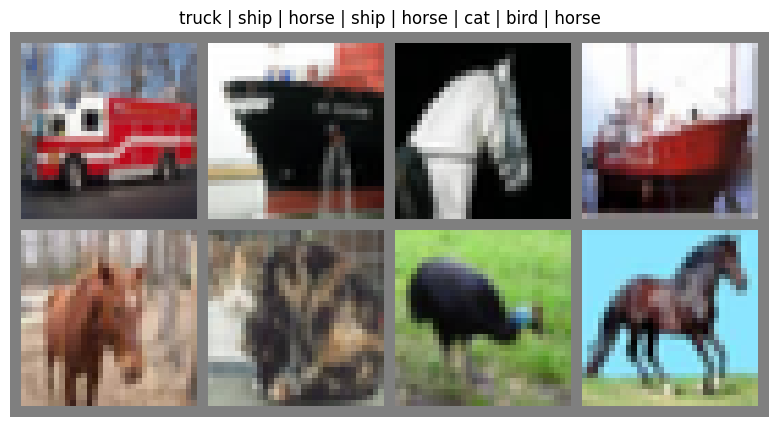


Images device: cuda:0
Labels device: cuda:0

MILESTONE 1 COMPLETE
Dataset: CIFAR-10
Classes: 10
Batch size: 32
Image batch shape: torch.Size([32, 3, 32, 32])
Device: cuda


In [5]:
# ============================================================
# PYTORCH PROJECT — MILESTONE 1
# DATA PIPELINE
# ============================================================

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader


# ============================================================
# 1. CHECK DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch Version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. CREATE A SIMPLE TENSOR
# ============================================================

x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
], dtype=torch.float32)

print("\nTensor:")
print(x)

print("Shape:", x.shape)
print("Data type:", x.dtype)
print("Device:", x.device)


# ============================================================
# 3. MOVE TENSOR TO GPU
# ============================================================

x = x.to(device)

print("Tensor moved to:", x.device)


# ============================================================
# 4. IMAGE TRANSFORMATION
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


# ============================================================
# 5. DOWNLOAD CIFAR-10
# ============================================================

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# 6. CLASS NAMES
# ============================================================

classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)


print("\nTraining Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))


# ============================================================
# 7. LOOK AT ONE IMAGE
# ============================================================

image, label = train_dataset[0]

print("\nSingle image shape:", image.shape)
print("Label number:", label)
print("Label name:", classes[label])


# ============================================================
# 8. CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


print("\nTraining batches:", len(train_loader))
print("Testing batches:", len(test_loader))


# ============================================================
# 9. GET ONE BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("\nBatch image shape:", images.shape)
print("Batch label shape:", labels.shape)

print("\nFirst 10 labels:")
print(labels[:10])


# ============================================================
# 10. CHECK FIRST IMAGE IN BATCH
# ============================================================

print("\nFirst image shape:")
print(images[0].shape)


# ============================================================
# 11. DISPLAY IMAGES
# ============================================================

def show_image_grid(images, labels):

    # Take first 8 images
    images = images[:8]
    labels = labels[:8]

    # Create image grid
    grid = torchvision.utils.make_grid(images, nrow=4)

    # Undo normalization
    grid = grid * 0.5 + 0.5

    # PyTorch → NumPy
    grid = grid.numpy()

    # CHW → HWC
    grid = np.transpose(grid, (1, 2, 0))

    # Display
    plt.figure(figsize=(10, 5))
    plt.imshow(grid)

    names = [classes[label.item()] for label in labels]

    plt.title(" | ".join(names))
    plt.axis("off")
    plt.show()


show_image_grid(images, labels)


# ============================================================
# 12. MOVE BATCH TO GPU
# ============================================================

images = images.to(device)
labels = labels.to(device)

print("\nImages device:", images.device)
print("Labels device:", labels.device)


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("MILESTONE 1 COMPLETE")
print("=" * 60)

print("Dataset: CIFAR-10")
print("Classes:", len(classes))
print("Batch size:", BATCH_SIZE)
print("Image batch shape:", images.shape)
print("Device:", device)

In [6]:
# ============================================================
# PYTORCH PROJECT — MILESTONE 2
# BUILD OUR FIRST CNN
# ============================================================

import torch
import torch.nn as nn


# ============================================================
# 1. CREATE CNN
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self):

        super().__init__()

        # First convolution
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Second convolution
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Activation
        self.relu = nn.ReLU()

        # Pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully connected layer
        self.fc1 = nn.Linear(
            64 * 8 * 8,
            128
        )

        # Final classification layer
        self.fc2 = nn.Linear(
            128,
            10
        )


    # ========================================================
    # 2. DEFINE HOW DATA MOVES THROUGH NETWORK
    # ========================================================

    def forward(self, x):

        print("Input:          ", x.shape)

        x = self.conv1(x)
        print("After Conv1:    ", x.shape)

        x = self.relu(x)

        x = self.pool(x)
        print("After Pool1:    ", x.shape)

        x = self.conv2(x)
        print("After Conv2:    ", x.shape)

        x = self.relu(x)

        x = self.pool(x)
        print("After Pool2:    ", x.shape)

        x = torch.flatten(x, 1)
        print("After Flatten:  ", x.shape)

        x = self.fc1(x)
        print("After FC1:      ", x.shape)

        x = self.relu(x)

        x = self.fc2(x)
        print("Final Output:   ", x.shape)

        return x


# ============================================================
# 3. CREATE MODEL
# ============================================================

model = SimpleCNN()


# ============================================================
# 4. MOVE MODEL TO GPU
# ============================================================

model = model.to(device)

print("\nModel device:")
print(next(model.parameters()).device)


# ============================================================
# 5. DISPLAY MODEL
# ============================================================

print("\n" + "=" * 60)
print("OUR CNN")
print("=" * 60)

print(model)


# ============================================================
# 6. COUNT PARAMETERS
# ============================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("\nTotal parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)


# ============================================================
# 7. SEND OUR IMAGE BATCH THROUGH CNN
# ============================================================

print("\n" + "=" * 60)
print("FORWARD PASS")
print("=" * 60)

outputs = model(images)


# ============================================================
# 8. CHECK OUTPUT
# ============================================================

print("\nOutput tensor shape:")
print(outputs.shape)


# ============================================================
# 9. LOOK AT FIRST IMAGE OUTPUT
# ============================================================

print("\nRaw output for first image:")

print(outputs[0])


# ============================================================
# 10. GET PREDICTION
# ============================================================

predicted_class = torch.argmax(
    outputs[0]
).item()

print("\nPredicted class number:")
print(predicted_class)

print("\nPredicted class name:")
print(classes[predicted_class])


# ============================================================
# 11. COMPARE WITH REAL ANSWER
# ============================================================

actual_class = labels[0].item()

print("\nActual class number:")
print(actual_class)

print("\nActual class name:")
print(classes[actual_class])


# ============================================================
# 12. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("MILESTONE 2 COMPLETE")
print("=" * 60)


Model device:
cuda:0

OUR CNN
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 545098
Trainable parameters: 545098

FORWARD PASS
Input:           torch.Size([32, 3, 32, 32])
After Conv1:     torch.Size([32, 32, 32, 32])
After Pool1:     torch.Size([32, 32, 16, 16])
After Conv2:     torch.Size([32, 64, 16, 16])
After Pool2:     torch.Size([32, 64, 8, 8])
After Flatten:   torch.Size([32, 4096])
After FC1:       torch.Size([32, 128])
Final Output:    torch.Size([32, 10])

Output tensor shape:
torch.Size([32, 10])

Raw output for first image:
tensor([-0.0353,  0.1137,  0.1238, -0.0766,  0.0571,  0.0428,  0.0174,  0.0099,
         0.0

In [7]:
# ============================================================
# PYTORCH PROJECT — MILESTONE 3
# TRAIN OUR CNN
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import time


# ============================================================
# 1. CLEAN CNN WITHOUT PRINT STATEMENTS
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            64 * 8 * 8,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )


    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.conv2(x)

        x = self.relu(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x


# ============================================================
# 2. CREATE FRESH MODEL
# ============================================================

model = SimpleCNN().to(device)

print("Model created.")
print("Device:", next(model.parameters()).device)


# ============================================================
# 3. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 4. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# ============================================================
# 5. NUMBER OF EPOCHS
# ============================================================

EPOCHS = 5


# ============================================================
# 6. STORE TRAINING HISTORY
# ============================================================

train_losses = []
train_accuracies = []


# ============================================================
# 7. START TRAINING
# ============================================================

print("\n" + "=" * 60)
print("TRAINING STARTED")
print("=" * 60)

start_time = time.time()


for epoch in range(EPOCHS):

    # Training mode
    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    # ========================================================
    # LOOP THROUGH TRAINING BATCHES
    # ========================================================

    for batch_number, (images, labels) in enumerate(train_loader):

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)


        # ----------------------------------------------------
        # STEP 1: REMOVE OLD GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # STEP 2: FORWARD PASS
        # ----------------------------------------------------

        outputs = model(images)


        # ----------------------------------------------------
        # STEP 3: CALCULATE LOSS
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # STEP 4: BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # STEP 5: UPDATE MODEL WEIGHTS
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # CALCULATE STATISTICS
        # ----------------------------------------------------

        running_loss += loss.item()


        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)


        correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # SHOW PROGRESS
        # ----------------------------------------------------

        if (batch_number + 1) % 300 == 0:

            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Batch [{batch_number+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )


    # ========================================================
    # CALCULATE EPOCH RESULTS
    # ========================================================

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total


    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)


    print("\n----------------------------------------")

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Average Loss: {epoch_loss:.4f}"
    )

    print(
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

    print("----------------------------------------\n")


# ============================================================
# 8. TRAINING TIME
# ============================================================

end_time = time.time()

training_time = end_time - start_time

print("=" * 60)
print("TRAINING FINISHED")
print("=" * 60)

print(
    f"Training time: {training_time:.2f} seconds"
)


# ============================================================
# 9. TEST MODEL
# ============================================================

model.eval()

correct = 0

total = 0

test_loss = 0.0


# ============================================================
# 10. DISABLE GRADIENT CALCULATION
# ============================================================

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)


        # Prediction
        outputs = model(images)


        # Test loss
        loss = criterion(
            outputs,
            labels
        )

        test_loss += loss.item()


        # Find predicted class
        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)


        correct += (
            predicted == labels
        ).sum().item()


# ============================================================
# 11. TEST RESULTS
# ============================================================

test_accuracy = 100 * correct / total

average_test_loss = test_loss / len(test_loader)


print("\n" + "=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(
    f"Test Loss: {average_test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)


# ============================================================
# 12. SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "cifar10_cnn.pth"
)

print("\nModel saved as:")
print("cifar10_cnn.pth")


# ============================================================
# 13. FINAL
# ============================================================

print("\n" + "=" * 60)
print("MILESTONE 3 COMPLETE")
print("=" * 60)

Model created.
Device: cuda:0

TRAINING STARTED
Epoch [1/5] Batch [300/1563] Loss: 1.2309
Epoch [1/5] Batch [600/1563] Loss: 1.5011
Epoch [1/5] Batch [900/1563] Loss: 1.4466
Epoch [1/5] Batch [1200/1563] Loss: 1.1954
Epoch [1/5] Batch [1500/1563] Loss: 1.1681

----------------------------------------
Epoch 1/5
Average Loss: 1.2907
Training Accuracy: 53.69%
----------------------------------------

Epoch [2/5] Batch [300/1563] Loss: 1.0920
Epoch [2/5] Batch [600/1563] Loss: 0.6623
Epoch [2/5] Batch [900/1563] Loss: 0.9006
Epoch [2/5] Batch [1200/1563] Loss: 0.9403
Epoch [2/5] Batch [1500/1563] Loss: 1.1536

----------------------------------------
Epoch 2/5
Average Loss: 0.9173
Training Accuracy: 67.66%
----------------------------------------

Epoch [3/5] Batch [300/1563] Loss: 0.9508
Epoch [3/5] Batch [600/1563] Loss: 1.0056
Epoch [3/5] Batch [900/1563] Loss: 0.7406
Epoch [3/5] Batch [1200/1563] Loss: 0.6616
Epoch [3/5] Batch [1500/1563] Loss: 0.6966

---------------------------------

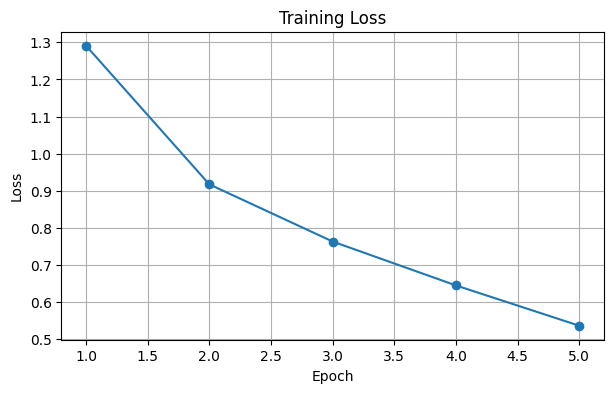

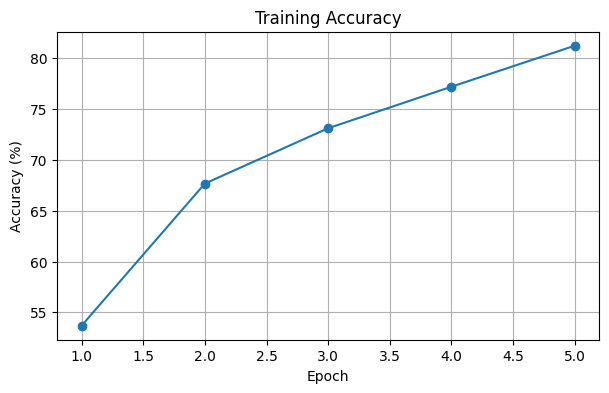

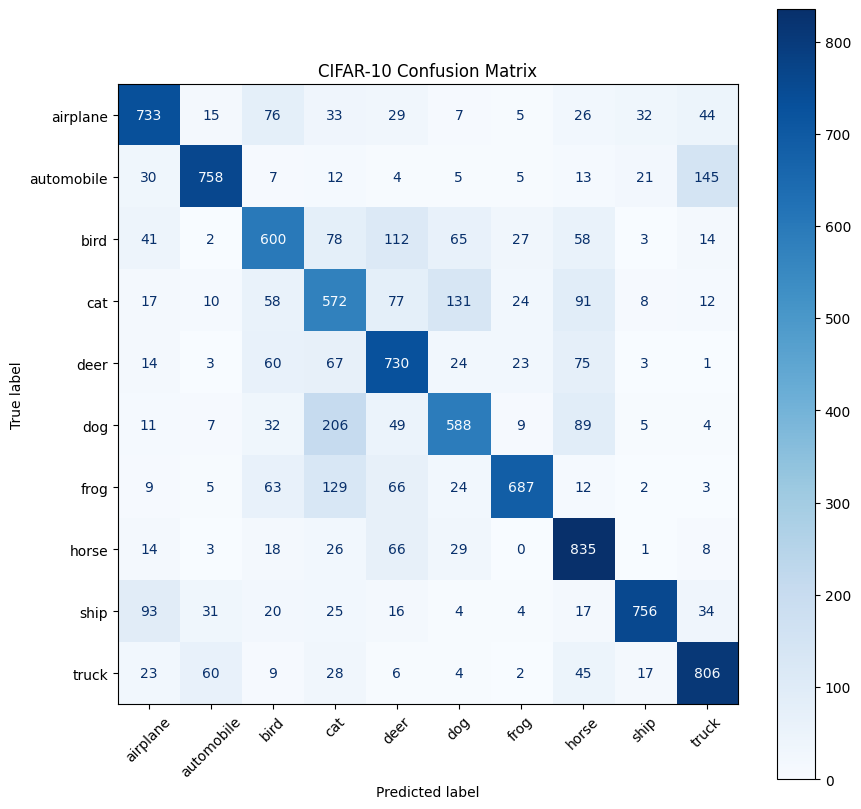


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane      0.744     0.733     0.739      1000
  automobile      0.848     0.758     0.800      1000
        bird      0.636     0.600     0.618      1000
         cat      0.486     0.572     0.526      1000
        deer      0.632     0.730     0.677      1000
         dog      0.667     0.588     0.625      1000
        frog      0.874     0.687     0.769      1000
       horse      0.662     0.835     0.739      1000
        ship      0.892     0.756     0.818      1000
       truck      0.753     0.806     0.778      1000

    accuracy                          0.707     10000
   macro avg      0.719     0.707     0.709     10000
weighted avg      0.719     0.707     0.709     10000


CLASS-WISE ACCURACY
airplane    : 73.30%
automobile  : 75.80%
bird        : 60.00%
cat         : 57.20%
deer        : 73.00%
dog         : 58.80%
frog        : 68.70%
horse       : 83.50%
ship        : 75.60%
truck   

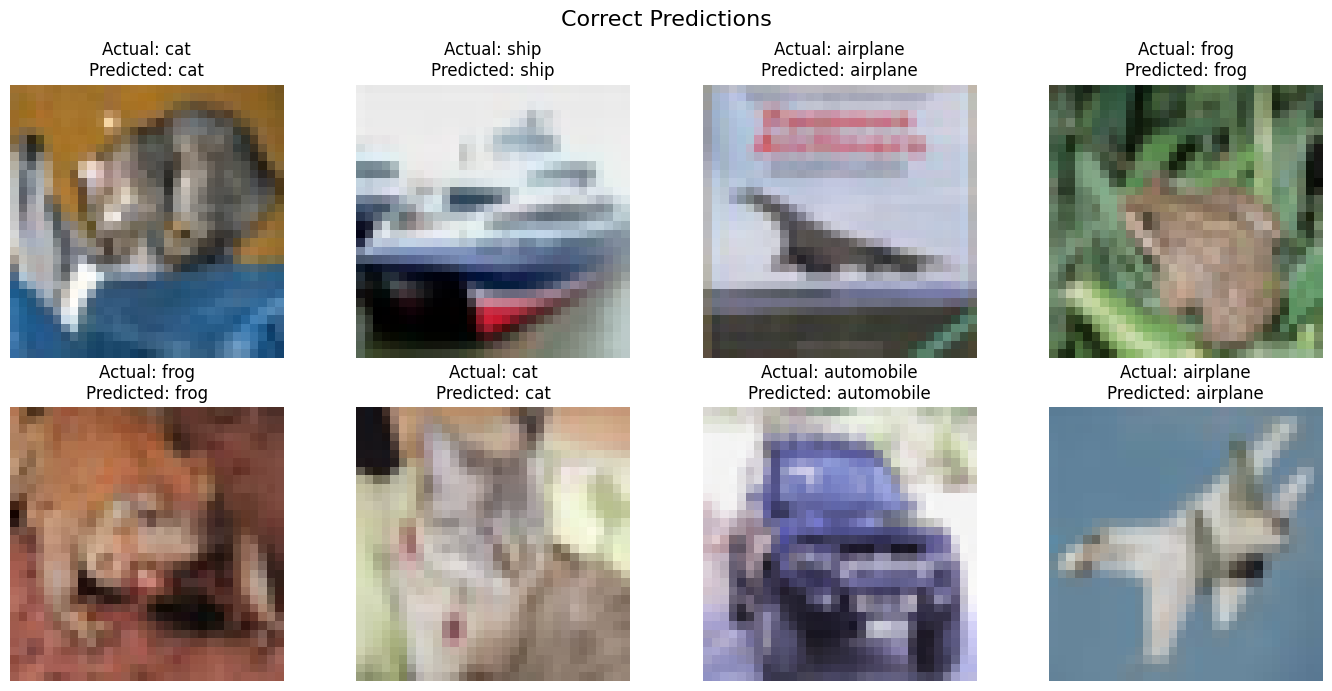

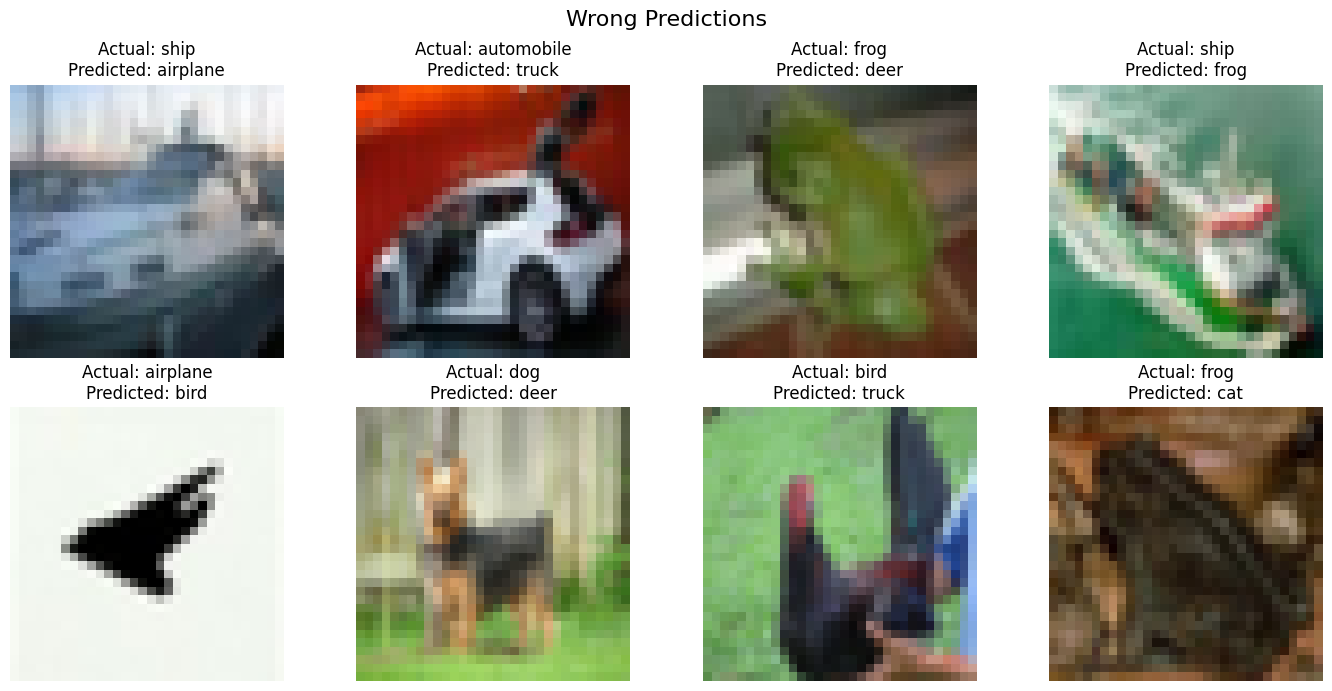


MODEL ANALYSIS
Best class: horse (83.50%)
Worst class: cat (57.20%)

MILESTONE 4 COMPLETE


In [8]:
# ============================================================
# PYTORCH PROJECT — MILESTONE 4
# MODEL EVALUATION AND VISUALIZATION
# ============================================================

import torch
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay


# ============================================================
# 1. TRAINING LOSS GRAPH
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()

plt.show()


# ============================================================
# 2. TRAINING ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.grid()

plt.show()


# ============================================================
# 3. COLLECT ALL TEST PREDICTIONS
# ============================================================

model.eval()

all_predictions = []
all_labels = []

correct_images = []
wrong_images = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        # Store predictions
        all_predictions.extend(
            predictions.cpu().numpy()
        )

        # Store actual labels
        all_labels.extend(
            labels.cpu().numpy()
        )


        # ====================================================
        # STORE SOME CORRECT AND WRONG EXAMPLES
        # ====================================================

        for i in range(len(labels)):

            image = images[i].cpu()

            actual = labels[i].item()

            predicted = predictions[i].item()


            if actual == predicted:

                if len(correct_images) < 8:

                    correct_images.append(
                        (image, actual, predicted)
                    )

            else:

                if len(wrong_images) < 8:

                    wrong_images.append(
                        (image, actual, predicted)
                    )


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("CIFAR-10 Confusion Matrix")

plt.show()


# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes,
        digits=3
    )
)


# ============================================================
# 6. CLASS-WISE ACCURACY
# ============================================================

print("\n" + "=" * 70)
print("CLASS-WISE ACCURACY")
print("=" * 70)


for i, class_name in enumerate(classes):

    class_indices = np.array(all_labels) == i

    class_predictions = np.array(all_predictions)[class_indices]

    class_labels = np.array(all_labels)[class_indices]

    accuracy = (
        class_predictions == class_labels
    ).mean() * 100

    print(
        f"{class_name:12s}: {accuracy:.2f}%"
    )


# ============================================================
# 7. FUNCTION TO DISPLAY IMAGE
# ============================================================

def prepare_image(image):

    # Undo normalization
    image = image * 0.5 + 0.5

    # CHW → HWC
    image = image.numpy()

    image = np.transpose(
        image,
        (1, 2, 0)
    )

    # Keep valid pixel range
    image = np.clip(
        image,
        0,
        1
    )

    return image


# ============================================================
# 8. SHOW CORRECT PREDICTIONS
# ============================================================

plt.figure(figsize=(14, 7))


for i, (image, actual, predicted) in enumerate(correct_images):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        prepare_image(image)
    )

    plt.title(
        f"Actual: {classes[actual]}\n"
        f"Predicted: {classes[predicted]}"
    )

    plt.axis("off")


plt.suptitle(
    "Correct Predictions",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. SHOW WRONG PREDICTIONS
# ============================================================

plt.figure(figsize=(14, 7))


for i, (image, actual, predicted) in enumerate(wrong_images):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        prepare_image(image)
    )

    plt.title(
        f"Actual: {classes[actual]}\n"
        f"Predicted: {classes[predicted]}"
    )

    plt.axis("off")


plt.suptitle(
    "Wrong Predictions",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. FIND BEST AND WORST CLASS
# ============================================================

class_accuracies = []


for i, class_name in enumerate(classes):

    class_indices = np.array(all_labels) == i

    class_predictions = np.array(all_predictions)[class_indices]

    class_labels = np.array(all_labels)[class_indices]

    accuracy = (
        class_predictions == class_labels
    ).mean() * 100

    class_accuracies.append(accuracy)


best_index = np.argmax(class_accuracies)

worst_index = np.argmin(class_accuracies)


print("\n" + "=" * 70)
print("MODEL ANALYSIS")
print("=" * 70)

print(
    f"Best class: {classes[best_index]} "
    f"({class_accuracies[best_index]:.2f}%)"
)

print(
    f"Worst class: {classes[worst_index]} "
    f"({class_accuracies[worst_index]:.2f}%)"
)


print("\n" + "=" * 70)
print("MILESTONE 4 COMPLETE")
print("=" * 70)

Device: cuda
Training images: 50000
Testing images: 10000

Improved CNN:
ImprovedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 620810

IMPROVED CNN TRAINING
Epoch 01/10 | Train Loss: 1.5769 | Train Acc: 41.79% | Test Loss: 1.2820 | Test Acc: 51.95%
Epo

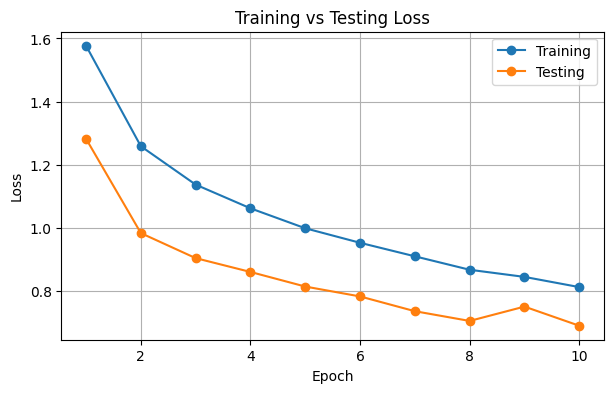

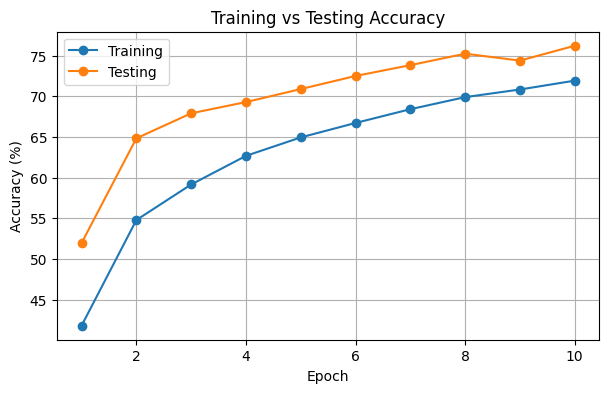


MODEL COMPARISON
Old CNN Test Accuracy: 70.65%
Improved CNN Best Accuracy: 76.22%
Best Epoch: 10

MILESTONE 5 COMPLETE


In [9]:
# ============================================================
# PYTORCH PROJECT — MILESTONE 5
# IMPROVE OUR CNN
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

from torch.utils.data import DataLoader


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 2. DATA AUGMENTATION FOR TRAINING
# ============================================================

train_transform = transforms.Compose([

    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


# ============================================================
# 3. NORMAL TRANSFORM FOR TESTING
# ============================================================

test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


# ============================================================
# 4. LOAD DATASETS
# ============================================================

train_dataset_improved = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset_improved = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)


# ============================================================
# 5. DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader_improved = DataLoader(
    train_dataset_improved,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader_improved = DataLoader(
    test_dataset_improved,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


print("Training images:", len(train_dataset_improved))
print("Testing images:", len(test_dataset_improved))


# ============================================================
# 6. IMPROVED CNN
# ============================================================

class ImprovedCNN(nn.Module):

    def __init__(self):

        super().__init__()


        # BLOCK 1
        self.conv1 = nn.Conv2d(
            3,
            32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(32)


        # BLOCK 2
        self.conv2 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(64)


        # BLOCK 3
        self.conv3 = nn.Conv2d(
            64,
            128,
            kernel_size=3,
            padding=1
        )

        self.bn3 = nn.BatchNorm2d(128)


        # COMMON LAYERS
        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            2,
            2
        )


        # DROPOUT
        self.dropout = nn.Dropout(0.5)


        # 32 → 16 → 8 → 4
        self.fc1 = nn.Linear(
            128 * 4 * 4,
            256
        )

        self.fc2 = nn.Linear(
            256,
            10
        )


    def forward(self, x):

        # BLOCK 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)


        # BLOCK 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)


        # BLOCK 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)


        # FLATTEN
        x = torch.flatten(
            x,
            1
        )


        # CLASSIFIER
        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x


# ============================================================
# 7. CREATE MODEL
# ============================================================

improved_model = ImprovedCNN().to(device)

print("\nImproved CNN:")
print(improved_model)


# ============================================================
# 8. COUNT PARAMETERS
# ============================================================

parameters = sum(
    p.numel()
    for p in improved_model.parameters()
)

print("\nTotal parameters:", parameters)


# ============================================================
# 9. LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# ============================================================
# 11. TRAINING SETTINGS
# ============================================================

EPOCHS = 10

train_losses_improved = []
train_accuracies_improved = []

test_losses_improved = []
test_accuracies_improved = []


# ============================================================
# 12. TRAINING
# ============================================================

print("\n" + "=" * 70)
print("IMPROVED CNN TRAINING")
print("=" * 70)

start_time = time.time()


for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    improved_model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader_improved:

        images = images.to(device)

        labels = labels.to(device)


        # Clear gradients
        optimizer.zero_grad()


        # Forward
        outputs = improved_model(images)


        # Loss
        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        # Statistics
        running_loss += loss.item()


        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)


        correct += (
            predicted == labels
        ).sum().item()


    train_loss = (
        running_loss /
        len(train_loader_improved)
    )


    train_accuracy = (
        100 * correct / total
    )


    train_losses_improved.append(
        train_loss
    )

    train_accuracies_improved.append(
        train_accuracy
    )


    # ========================================================
    # TEST AFTER EACH EPOCH
    # ========================================================

    improved_model.eval()

    test_loss = 0.0

    test_correct = 0

    test_total = 0


    with torch.no_grad():

        for images, labels in test_loader_improved:

            images = images.to(device)

            labels = labels.to(device)


            outputs = improved_model(images)


            loss = criterion(
                outputs,
                labels
            )


            test_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )


            test_total += labels.size(0)


            test_correct += (
                predicted == labels
            ).sum().item()


    average_test_loss = (
        test_loss /
        len(test_loader_improved)
    )


    test_accuracy = (
        100 *
        test_correct /
        test_total
    )


    test_losses_improved.append(
        average_test_loss
    )

    test_accuracies_improved.append(
        test_accuracy
    )


    # ========================================================
    # PRINT EPOCH RESULT
    # ========================================================

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Loss: {average_test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.2f}%"
    )


# ============================================================
# 13. TRAINING TIME
# ============================================================

training_time = time.time() - start_time

print(
    f"\nTraining Time: {training_time:.2f} seconds"
)


# ============================================================
# 14. SAVE IMPROVED MODEL
# ============================================================

torch.save(
    improved_model.state_dict(),
    "cifar10_improved_cnn.pth"
)

print(
    "Saved: cifar10_improved_cnn.pth"
)


# ============================================================
# 15. LOSS GRAPH
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses_improved,
    marker="o",
    label="Training"
)

plt.plot(
    range(1, EPOCHS + 1),
    test_losses_improved,
    marker="o",
    label="Testing"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Testing Loss")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 16. ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies_improved,
    marker="o",
    label="Training"
)

plt.plot(
    range(1, EPOCHS + 1),
    test_accuracies_improved,
    marker="o",
    label="Testing"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Testing Accuracy")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 17. COMPARISON
# ============================================================

best_test_accuracy = max(
    test_accuracies_improved
)

best_epoch = (
    test_accuracies_improved.index(
        best_test_accuracy
    ) + 1
)


print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print("Old CNN Test Accuracy: 70.65%")

print(
    f"Improved CNN Best Accuracy: "
    f"{best_test_accuracy:.2f}%"
)

print(
    f"Best Epoch: {best_epoch}"
)


print("\n" + "=" * 70)
print("MILESTONE 5 COMPLETE")
print("=" * 70)

Device: cuda
Training: 45000
Validation: 5000
Testing: 10000
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]



ResNet final layer:
Linear(in_features=512, out_features=10, bias=True)

RESNET18 TRAINING
Epoch 1/5 | Train Loss: 0.4058 | Train Acc: 86.33% | Val Loss: 0.2070 | Val Acc: 92.92%
Epoch 2/5 | Train Loss: 0.1986 | Train Acc: 93.23% | Val Loss: 0.1827 | Val Acc: 93.88%
Epoch 3/5 | Train Loss: 0.1385 | Train Acc: 95.24% | Val Loss: 0.1824 | Val Acc: 93.84%
Epoch 4/5 | Train Loss: 0.1051 | Train Acc: 96.51% | Val Loss: 0.1843 | Val Acc: 93.90%
Epoch 5/5 | Train Loss: 0.0865 | Train Acc: 97.01% | Val Loss: 0.1837 | Val Acc: 94.20%

FINAL RESULTS
Best Validation Accuracy: 94.20%
Final Test Accuracy: 93.87%

Saved: cifar10_resnet18.pth


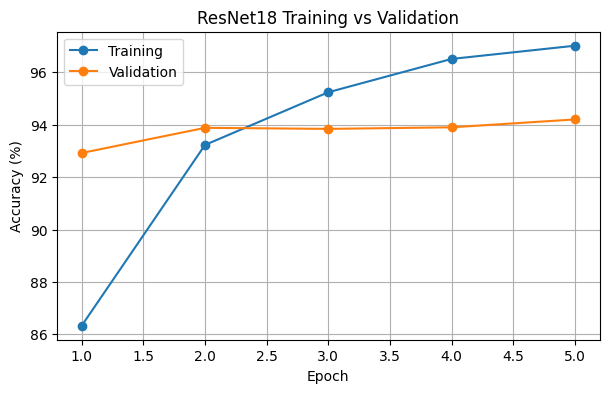

In [10]:
# ============================================================
# MILESTONE 6
# TRANSFER LEARNING WITH RESNET18
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import copy

from torch.utils.data import DataLoader, random_split
from torchvision.models import resnet18, ResNet18_Weights


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 2. CLASSES
# ============================================================

classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)


# ============================================================
# 3. TRANSFORMS
# ============================================================

# ResNet was pretrained on ImageNet, so we use ImageNet
# normalization values.

train_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 4. LOAD DATA
# ============================================================

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)


# ============================================================
# 5. TRAIN / VALIDATION SPLIT
# ============================================================

train_size = 45000
validation_size = 5000


train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size],
    generator=torch.Generator().manual_seed(42)
)


# Validation should not use random augmentation.

validation_dataset.dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=test_transform
)


# ============================================================
# 6. DATALOADERS
# ============================================================

BATCH_SIZE = 64


train_loader_resnet = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


validation_loader_resnet = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


test_loader_resnet = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Training:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Testing:", len(test_dataset))


# ============================================================
# 7. LOAD PRETRAINED RESNET18
# ============================================================

weights = ResNet18_Weights.DEFAULT

resnet_model = resnet18(
    weights=weights
)


# ============================================================
# 8. REPLACE FINAL CLASSIFIER
# ============================================================

number_of_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(
    number_of_features,
    10
)


resnet_model = resnet_model.to(device)


print("\nResNet final layer:")
print(resnet_model.fc)


# ============================================================
# 9. LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    resnet_model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)


# ============================================================
# 11. SETTINGS
# ============================================================

EPOCHS = 5

train_history = []
validation_history = []

best_validation_accuracy = 0.0
best_model_weights = copy.deepcopy(
    resnet_model.state_dict()
)


# ============================================================
# 12. TRAINING
# ============================================================

print("\n" + "=" * 70)
print("RESNET18 TRAINING")
print("=" * 70)


start_time = time.time()


for epoch in range(EPOCHS):


    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    resnet_model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0.0


    for images, labels in train_loader_resnet:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = resnet_model(images)


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()


        optimizer.step()


        train_loss += loss.item()


        predictions = outputs.argmax(
            dim=1
        )


        train_total += labels.size(0)


        train_correct += (
            predictions == labels
        ).sum().item()


    train_accuracy = (
        100 *
        train_correct /
        train_total
    )


    average_train_loss = (
        train_loss /
        len(train_loader_resnet)
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    resnet_model.eval()

    validation_correct = 0
    validation_total = 0
    validation_loss = 0.0


    with torch.no_grad():

        for images, labels in validation_loader_resnet:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            outputs = resnet_model(images)


            loss = criterion(
                outputs,
                labels
            )


            validation_loss += loss.item()


            predictions = outputs.argmax(
                dim=1
            )


            validation_total += labels.size(0)


            validation_correct += (
                predictions == labels
            ).sum().item()


    validation_accuracy = (
        100 *
        validation_correct /
        validation_total
    )


    average_validation_loss = (
        validation_loss /
        len(validation_loader_resnet)
    )


    train_history.append(
        train_accuracy
    )

    validation_history.append(
        validation_accuracy
    )


    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {average_validation_loss:.4f} | "
        f"Val Acc: {validation_accuracy:.2f}%"
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy

        best_model_weights = copy.deepcopy(
            resnet_model.state_dict()
        )


# ============================================================
# 13. RESTORE BEST MODEL
# ============================================================

resnet_model.load_state_dict(
    best_model_weights
)


# ============================================================
# 14. FINAL TEST
# ============================================================

resnet_model.eval()

correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader_resnet:

        images = images.to(device)
        labels = labels.to(device)


        outputs = resnet_model(images)


        predictions = outputs.argmax(
            dim=1
        )


        total += labels.size(0)


        correct += (
            predictions == labels
        ).sum().item()


test_accuracy = (
    100 * correct / total
)


# ============================================================
# 15. RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    f"Best Validation Accuracy: "
    f"{best_validation_accuracy:.2f}%"
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy:.2f}%"
)


# ============================================================
# 16. SAVE MODEL
# ============================================================

torch.save(
    resnet_model.state_dict(),
    "cifar10_resnet18.pth"
)


print(
    "\nSaved: cifar10_resnet18.pth"
)


# ============================================================
# 17. GRAPH
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, EPOCHS + 1),
    train_history,
    marker="o",
    label="Training"
)

plt.plot(
    range(1, EPOCHS + 1),
    validation_history,
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet18 Training vs Validation"
)

plt.legend()
plt.grid()

plt.show()

In [11]:
# ================================================================
# PYTORCH IMAGE INTELLIGENCE
# MILESTONES 7–10
# ONE COMPLETE GOOGLE COLAB CELL
#
# M7  = Real Image Prediction
# M8  = Streamlit Web App
# M9  = Supabase Database
# M10 = Analytics Dashboard
# ================================================================

from pathlib import Path
import zipfile


# ================================================================
# 0. CHECK TRAINED MODEL
# ================================================================

MODEL_PATH = Path("cifar10_resnet18.pth")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        "cifar10_resnet18.pth not found. "
        "Run Milestone 6 first."
    )

print("✓ Trained model found")


# ================================================================
# 1. CREATE COMPLETE STREAMLIT APP
# ================================================================

app_code = r'''
import streamlit as st

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms

from torchvision.models import resnet18

from PIL import Image

import pandas as pd


# ================================================================
# PAGE CONFIGURATION
# ================================================================

st.set_page_config(
    page_title="PyTorch Image Intelligence",
    page_icon="🧠",
    layout="wide"
)


# ================================================================
# CIFAR-10 CLASSES
# ================================================================

CLASSES = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)


# ================================================================
# DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ================================================================
# LOAD MODEL
# ================================================================

@st.cache_resource
def load_model():

    model = resnet18(
        weights=None
    )

    features = model.fc.in_features

    model.fc = nn.Linear(
        features,
        len(CLASSES)
    )

    state_dict = torch.load(
        "cifar10_resnet18.pth",
        map_location=DEVICE
    )

    model.load_state_dict(
        state_dict
    )

    model = model.to(
        DEVICE
    )

    model.eval()

    return model


model = load_model()


# ================================================================
# IMAGE TRANSFORM
# ================================================================

prediction_transform = transforms.Compose([

    transforms.Resize(
        (128, 128)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ================================================================
# MILESTONE 7
# PREDICT REAL IMAGE
# ================================================================

def predict_image(image):

    # Convert image to tensor
    tensor = prediction_transform(
        image
    )

    # Add batch dimension
    # [3,128,128] -> [1,3,128,128]
    tensor = tensor.unsqueeze(
        0
    )

    # Move tensor to device
    tensor = tensor.to(
        DEVICE
    )

    # Prediction
    with torch.no_grad():

        outputs = model(
            tensor
        )

        probabilities = F.softmax(
            outputs,
            dim=1
        )[0]

    # Move back to CPU
    probabilities = probabilities.cpu()

    # Get top 3 predictions
    values, indices = torch.topk(
        probabilities,
        k=3
    )

    results = []

    for value, index in zip(
        values,
        indices
    ):

        results.append({

            "class":
                CLASSES[
                    index.item()
                ],

            "confidence":
                float(
                    value.item()
                    * 100
                )
        })

    return results


# ================================================================
# MILESTONE 9
# SUPABASE CONNECTION
# ================================================================

@st.cache_resource
def connect_supabase():

    try:

        from supabase import create_client

        url = st.secrets[
            "SUPABASE_URL"
        ]

        key = st.secrets[
            "SUPABASE_KEY"
        ]

        client = create_client(
            url,
            key
        )

        return client

    except Exception:

        return None


supabase = connect_supabase()


# ================================================================
# SAVE PREDICTION TO DATABASE
# ================================================================

def save_prediction(
    filename,
    results
):

    if supabase is None:
        return False

    try:

        data = {

            "filename":
                filename,

            "predicted_class":
                results[0]["class"],

            "confidence":
                results[0]["confidence"],

            "second_prediction":
                results[1]["class"],

            "second_confidence":
                results[1]["confidence"],

            "third_prediction":
                results[2]["class"],

            "third_confidence":
                results[2]["confidence"]
        }

        supabase.table(
            "predictions"
        ).insert(
            data
        ).execute()

        return True

    except Exception:

        return False


# ================================================================
# LOAD DATABASE HISTORY
# ================================================================

def load_prediction_history():

    if supabase is None:
        return None

    try:

        response = (
            supabase
            .table(
                "predictions"
            )
            .select("*")
            .order(
                "created_at",
                desc=True
            )
            .execute()
        )

        return response.data

    except Exception:

        return None


# ================================================================
# SIDEBAR
# ================================================================

st.sidebar.title(
    "🧠 PyTorch AI"
)

page = st.sidebar.radio(
    "Navigation",
    [
        "Classifier",
        "Analytics",
        "About"
    ]
)

st.sidebar.divider()

st.sidebar.write(
    f"Device: **{DEVICE}**"
)

st.sidebar.write(
    "Model: **ResNet18**"
)

st.sidebar.write(
    "Test Accuracy: **93.87%**"
)


if supabase is not None:

    st.sidebar.success(
        "Database connected"
    )

else:

    st.sidebar.warning(
        "Database not configured"
    )


# ================================================================
# MILESTONE 8
# STREAMLIT CLASSIFIER PAGE
# ================================================================

if page == "Classifier":

    st.title(
        "🧠 PyTorch Image Intelligence"
    )

    st.write(
        "Upload an image and the PyTorch ResNet18 "
        "model will classify it."
    )

    st.info(
        "Supported classes: airplane, automobile, bird, "
        "cat, deer, dog, frog, horse, ship and truck."
    )


    uploaded_file = st.file_uploader(
        "Upload an image",
        type=[
            "jpg",
            "jpeg",
            "png"
        ]
    )


    if uploaded_file is None:

        st.write(
            "Upload an image to begin."
        )


    else:

        try:

            image = Image.open(
                uploaded_file
            ).convert(
                "RGB"
            )

        except Exception:

            st.error(
                "Could not read this image."
            )

            st.stop()


        # ========================================================
        # RUN MODEL
        # ========================================================

        results = predict_image(
            image
        )


        # ========================================================
        # CREATE TWO COLUMNS
        # ========================================================

        image_column, prediction_column = st.columns(
            2
        )


        # ========================================================
        # DISPLAY IMAGE
        # ========================================================

        with image_column:

            st.subheader(
                "Uploaded Image"
            )

            st.image(
                image,
                use_container_width=True
            )


        # ========================================================
        # DISPLAY PREDICTIONS
        # ========================================================

        with prediction_column:

            st.subheader(
                "AI Prediction"
            )


            st.metric(
                "Predicted Class",
                results[0]["class"].title()
            )


            st.metric(
                "Confidence",
                f'{results[0]["confidence"]:.2f}%'
            )


            st.subheader(
                "Top 3 Predictions"
            )


            for rank, result in enumerate(
                results,
                start=1
            ):

                st.write(
                    f'**{rank}. '
                    f'{result["class"].title()}** '
                    f'— '
                    f'{result["confidence"]:.2f}%'
                )

                st.progress(
                    min(
                        result["confidence"]
                        / 100,
                        1.0
                    )
                )


        # ========================================================
        # SAVE TO DATABASE
        # ========================================================

        file_identifier = (
            uploaded_file.name
            + "_"
            + str(
                uploaded_file.size
            )
        )


        if "saved_prediction" not in st.session_state:

            st.session_state[
                "saved_prediction"
            ] = None


        if (
            st.session_state[
                "saved_prediction"
            ]
            != file_identifier
        ):

            saved = save_prediction(
                uploaded_file.name,
                results
            )


            if saved:

                st.session_state[
                    "saved_prediction"
                ] = file_identifier

                st.success(
                    "Prediction saved to database."
                )


# ================================================================
# MILESTONE 10
# ANALYTICS DASHBOARD
# ================================================================

elif page == "Analytics":

    st.title(
        "📊 Prediction Analytics"
    )


    if supabase is None:

        st.warning(
            "Connect Supabase to enable analytics."
        )


    else:

        data = load_prediction_history()


        if data is None:

            st.error(
                "Could not retrieve prediction history."
            )


        elif len(data) == 0:

            st.info(
                "No predictions stored yet."
            )


        else:

            df = pd.DataFrame(
                data
            )


            # ====================================================
            # SUMMARY METRICS
            # ====================================================

            col1, col2, col3 = st.columns(
                3
            )


            total_predictions = len(
                df
            )


            average_confidence = (
                df["confidence"]
                .astype(float)
                .mean()
            )


            most_common_class = (
                df["predicted_class"]
                .value_counts()
                .idxmax()
            )


            with col1:

                st.metric(
                    "Total Predictions",
                    total_predictions
                )


            with col2:

                st.metric(
                    "Average Confidence",
                    f"{average_confidence:.2f}%"
                )


            with col3:

                st.metric(
                    "Most Predicted",
                    most_common_class.title()
                )


            # ====================================================
            # PREDICTION DISTRIBUTION
            # ====================================================

            st.subheader(
                "Prediction Distribution"
            )


            class_distribution = (
                df["predicted_class"]
                .value_counts()
            )


            st.bar_chart(
                class_distribution
            )


            # ====================================================
            # CONFIDENCE BY CLASS
            # ====================================================

            st.subheader(
                "Average Confidence by Class"
            )


            confidence_by_class = (
                df
                .groupby(
                    "predicted_class"
                )["confidence"]
                .mean()
                .sort_values(
                    ascending=False
                )
            )


            st.bar_chart(
                confidence_by_class
            )


            # ====================================================
            # RECENT PREDICTIONS
            # ====================================================

            st.subheader(
                "Recent Predictions"
            )


            columns_to_show = [

                "filename",

                "predicted_class",

                "confidence",

                "second_prediction",

                "second_confidence",

                "third_prediction",

                "third_confidence",

                "created_at"
            ]


            existing_columns = [

                column

                for column in columns_to_show

                if column in df.columns
            ]


            st.dataframe(
                df[
                    existing_columns
                ],
                use_container_width=True
            )


# ================================================================
# ABOUT PAGE
# ================================================================

else:

    st.title(
        "ℹ️ About This Project"
    )


    st.write(
        """
        This is an end-to-end computer vision application
        developed while learning PyTorch.
        """
    )


    st.subheader(
        "Model Development"
    )


    st.write(
        """
        **CNN from Scratch:** 70.65% test accuracy

        **Improved CNN:** 76.22% test accuracy

        **ResNet18 Transfer Learning:** 93.87% test accuracy
        """
    )


    st.subheader(
        "AI Pipeline"
    )


    st.code(
        """
Image Upload
     ↓
Image Preprocessing
     ↓
PyTorch
     ↓
ResNet18
     ↓
Softmax
     ↓
Top-3 Predictions
     ↓
Supabase Database
     ↓
Analytics Dashboard
        """
    )


    st.subheader(
        "Technology Stack"
    )


    st.write(
        """
        - PyTorch
        - Torchvision
        - ResNet18
        - Transfer Learning
        - Streamlit
        - Supabase
        - Pandas
        """
    )


# ================================================================
# FOOTER
# ================================================================

st.divider()

st.caption(
    "PyTorch Image Intelligence • PyTorch + Streamlit"
)
'''


with open(
    "app.py",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        app_code
    )

print("✓ app.py created")


# ================================================================
# 2. CREATE REQUIREMENTS.TXT
# ================================================================

requirements = """
streamlit
torch
torchvision
Pillow
pandas
supabase
"""


with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        requirements.strip()
    )

print("✓ requirements.txt created")


# ================================================================
# 3. CREATE .GITIGNORE
# ================================================================

gitignore = """
.streamlit/secrets.toml
__pycache__/
*.pyc
.ipynb_checkpoints/
"""


with open(
    ".gitignore",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        gitignore.strip()
    )

print("✓ .gitignore created")


# ================================================================
# 4. CREATE SUPABASE SQL
# ================================================================

sql_code = """
CREATE TABLE IF NOT EXISTS predictions (

    id BIGINT
    GENERATED BY DEFAULT AS IDENTITY
    PRIMARY KEY,

    filename TEXT NOT NULL,

    predicted_class TEXT NOT NULL,

    confidence DOUBLE PRECISION NOT NULL,

    second_prediction TEXT,

    second_confidence DOUBLE PRECISION,

    third_prediction TEXT,

    third_confidence DOUBLE PRECISION,

    created_at TIMESTAMPTZ
    DEFAULT NOW()
);
"""


with open(
    "supabase_setup.sql",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        sql_code.strip()
    )

print("✓ supabase_setup.sql created")




✓ Trained model found
✓ app.py created
✓ requirements.txt created
✓ .gitignore created
✓ supabase_setup.sql created


In [12]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 71.3 MB/s eta 0:00:00


In [13]:
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

In [14]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

2026-10-05T16:08:56Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-10-05T16:08:56Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-10-05T16:09:00Z INF +--------------------------------------------------------------------------------------------+
2026-10-05T16:09:00Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-10-05T16:09:00Z INF |  https://marketplace-matter-values-framing.trycloudfla